## Camden LSOA

In [1]:
import os
import pandas as pd
import geopandas as gpd

BASE = "/Users/alexia/Documents/CASA/Dissertation"

DEMAND_CSV = os.path.join(BASE, "05_processed", "demand_london.csv")
LSOA_SHP   = os.path.join(BASE, "03_data", "demand", "spatial", "LSOA_2021_EW_BGC_V5.shp")

demand = pd.read_csv(DEMAND_CSV)
lsoa_gdf = gpd.read_file(LSOA_SHP).to_crs(epsg=27700)

if "LSOA21CD" in lsoa_gdf.columns:
    lsoa_gdf = lsoa_gdf.rename(columns={"LSOA21CD": "lsoa_code"})

# demand_london.csv already has lad_name, demand, demand_norm — no need to redo the Di formula here
lsoa_demand = lsoa_gdf.merge(
    demand[["lsoa_code", "lsoa_name", "lad_name", "demand", "demand_norm", "imd_decile"]],
    on="lsoa_code",
    how="left"
)

# Filter to Camden LSOAs only
camden_lsoa = lsoa_demand[lsoa_demand["lad_name"] == "Camden"].reset_index(drop=True)
print("Camden LSOA count:", len(camden_lsoa))
print("Missing demand values in Camden subset:", camden_lsoa["demand"].isna().sum())

# Dissolved Camden boundary — feed this into 2a to spatially filter OSM candidate points
camden_boundary = camden_lsoa.geometry.union_all()
print("Camden boundary bounds (BNG, metres):", camden_boundary.bounds)

# Demand points for the p-median model = Camden LSOA centroids (2b)
camden_demand = camden_lsoa.copy()
camden_demand["geometry"] = camden_demand.geometry.centroid
print(camden_demand[["lsoa_code", "lsoa_name", "demand", "demand_norm"]].to_string())

Camden LSOA count: 130
Missing demand values in Camden subset: 0
Camden boundary bounds (BNG, metres): (523954.4780000001, 180965.35799999908, 531554.8607000001, 187603.64100000076)
     lsoa_code    lsoa_name     demand  demand_norm
0    E01000842  Camden 011A  28.018020     0.202365
1    E01000843  Camden 014A  21.655768     0.144579
2    E01000844  Camden 011B  29.833709     0.218856
3    E01000845  Camden 014B  30.018920     0.220538
4    E01000846  Camden 014C  29.903927     0.219493
5    E01000847  Camden 014D  36.857933     0.282654
6    E01000848  Camden 011C  25.330939     0.177959
7    E01000849  Camden 011D  18.334902     0.114417
8    E01000850  Camden 026A  12.479286     0.061233
9    E01000851  Camden 026B  12.453719     0.061001
10   E01000853  Camden 029H  11.168150     0.049324
11   E01000855  Camden 028A   8.508593     0.025169
12   E01000856  Camden 019A  23.422351     0.160624
13   E01000857  Camden 018A  30.102836     0.221300
14   E01000858  Camden 018B  35.388621

In [2]:
import os
import glob
import geopandas as gpd

BASE = "/Users/alexia/Documents/CASA/Dissertation"
OSM_DIR = os.path.join(BASE, "03_data", "supply", "osm")

# recursive glob — works whether the .shp files sit directly in osm/, or one level
# deeper inside the unzipped "greater-london-latest-free" folder
shp_files = sorted(glob.glob(os.path.join(OSM_DIR, "**", "*.shp"), recursive=True))
print(f"Found {len(shp_files)} shapefiles under {OSM_DIR}:\n")
for f in shp_files:
    print(os.path.relpath(f, OSM_DIR))

# Geofabrik puts car parks in the "traffic" layer, tagged fclass = 'parking'
traffic_files = [f for f in shp_files if "traffic" in os.path.basename(f).lower()]

for f in traffic_files:
    print("\n--- Inspecting:", os.path.basename(f), "---")
    gdf = gpd.read_file(f)
    print("Columns:", gdf.columns.tolist())
    print("CRS:", gdf.crs)
    print("Row count:", len(gdf))
    if "fclass" in gdf.columns:
        print("fclass value counts:")
        print(gdf["fclass"].value_counts())

Found 20 shapefiles under /Users/alexia/Documents/CASA/Dissertation/03_data/supply/osm:

greater-london- latest-free/gis_osm_adminareas_a_free_1.shp
greater-london- latest-free/gis_osm_buildings_a_free_1.shp
greater-london- latest-free/gis_osm_landuse_a_free_1.shp
greater-london- latest-free/gis_osm_natural_a_free_1.shp
greater-london- latest-free/gis_osm_natural_free_1.shp
greater-london- latest-free/gis_osm_places_a_free_1.shp
greater-london- latest-free/gis_osm_places_free_1.shp
greater-london- latest-free/gis_osm_pofw_a_free_1.shp
greater-london- latest-free/gis_osm_pofw_free_1.shp
greater-london- latest-free/gis_osm_pois_a_free_1.shp
greater-london- latest-free/gis_osm_pois_free_1.shp
greater-london- latest-free/gis_osm_protected_areas_a_free_1.shp
greater-london- latest-free/gis_osm_railways_free_1.shp
greater-london- latest-free/gis_osm_roads_free_1.shp
greater-london- latest-free/gis_osm_traffic_a_free_1.shp
greater-london- latest-free/gis_osm_traffic_free_1.shp
greater-london-

candidate points

In [4]:
TRAFFIC_SHP = os.path.join(BASE, "03_data", "supply", "osm",
                            "greater-london-latest-free", "gis_osm_traffic_a_free_1.shp")

traffic = gpd.read_file(TRAFFIC_SHP).to_crs(epsg=27700)

# Car parking polygons only — parking_bicycle is bike parking, not relevant for EV charging siting
parking = traffic[traffic["fclass"] == "parking"].copy()
print("Parking polygons across Greater London:", len(parking))

# Filter polygons to Camden boundary first (catches lots straddling the boundary line),
# then take centroids of the surviving subset
parking_camden = parking[parking.geometry.intersects(camden_boundary)].reset_index(drop=True)
print("Parking polygons intersecting Camden boundary:", len(parking_camden))

candidate_sites = parking_camden.copy()
candidate_sites["geometry"] = candidate_sites.geometry.centroid
candidate_sites["site_id"] = ["S" + str(i + 1).zfill(3) for i in range(len(candidate_sites))]
candidate_sites["x"] = candidate_sites.geometry.x   # EPSG:27700, metres
candidate_sites["y"] = candidate_sites.geometry.y   # EPSG:27700, metres

candidate_sites_out = candidate_sites[["site_id", "osm_id", "name", "x", "y"]]

output_path = os.path.join(BASE, "05_processed", "candidate_sites_camden.csv")
candidate_sites_out.to_csv(output_path, index=False)
print("Saved to:", output_path)
print(candidate_sites_out.head(10).to_string())

Parking polygons across Greater London: 16933
Parking polygons intersecting Camden boundary: 347
Saved to: /Users/alexia/Documents/CASA/Dissertation/05_processed/candidate_sites_camden.csv
  site_id    osm_id                   name              x              y
0    S001   5043306                    NaN  527095.624340  185941.521310
1    S002  26709559     London Zoo Parking  528448.736776  183610.037164
2    S003  26832232   George Mews Car Park  529240.761565  182598.090359
3    S004  29233515                    NaN  528319.622535  185756.053578
4    S005  30048856          Kenwood House  526782.670785  187446.888038
5    S006  30689703                    NaN  526192.248133  186444.067796
6    S007  32261846       Bucklebury House  529031.459177  182482.395058
7    S008  42958244  Saffron Hill Car Park  531432.525628  181950.364277
8    S009  43312307                    NaN  529642.347867  183533.673893
9    S010  49121522                    NaN  527334.375409  185299.855035


### distance matrix + PuLP p-median

In [7]:
import numpy as np
from scipy.spatial.distance import cdist
import pulp

# Coordinates for demand points (i) and candidate sites (j), both already EPSG:27700 (metres)
demand_coords = np.column_stack([camden_demand.geometry.x, camden_demand.geometry.y])
site_coords   = candidate_sites_out[["x", "y"]].values

# Euclidean distance matrix: rows = demand points i, columns = candidate sites j
dist_matrix = cdist(demand_coords, site_coords)
print("Distance matrix shape:", dist_matrix.shape)
print("Distance range (metres):", dist_matrix.min().round(1), "-", dist_matrix.max().round(1))

n_i = dist_matrix.shape[0]
n_j = dist_matrix.shape[1]
D = camden_demand["demand"].values
p = 5

prob = pulp.LpProblem("toy_pmedian_camden", pulp.LpMinimize)

# y_j: binary — whether candidate site j is opened
y = pulp.LpVariable.dicts("y", range(n_j), cat="Binary")

# x_ij: relaxed to continuous [0,1]. With y fixed, the optimal assignment subproblem is
# naturally integral (each demand point goes 100% to its nearest OPEN site), so this gives
# the same optimal solution as full binary x while solving much faster at this scale
x = pulp.LpVariable.dicts("x", (range(n_i), range(n_j)), lowBound=0, upBound=1, cat="Continuous")

# Objective: minimise Sum Di * d(i,j) * x_ij
prob += pulp.lpSum(D[i] * dist_matrix[i][j] * x[i][j] for i in range(n_i) for j in range(n_j))

# Constraint: exactly p sites opened
prob += pulp.lpSum(y[j] for j in range(n_j)) == p

# Constraint: each demand point assigned to exactly one site
for i in range(n_i):
    prob += pulp.lpSum(x[i][j] for j in range(n_j)) == 1

# Constraint: demand can only be assigned to an open site
for i in range(n_i):
    for j in range(n_j):
        prob += x[i][j] <= y[j]

prob.solve(pulp.PULP_CBC_CMD(msg=True))
print("\nSolver status:", pulp.LpStatus[prob.status])
print("Objective value:", round(pulp.value(prob.objective), 1))

selected_idx = [j for j in range(n_j) if y[j].value() > 0.5]
selected = candidate_sites_out.iloc[selected_idx]
print(f"\n{len(selected)} sites selected:")
print(selected[["site_id", "osm_id", "name", "x", "y"]].to_string())

Distance matrix shape: (130, 347)
Distance range (metres): 5.6 - 8167.7
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/b89ae016b11e4305856ea842e6d2fbc3-pulp.mps -timeMode elapsed -solve -printingOptions all -solution /var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/b89ae016b11e4305856ea842e6d2fbc3-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 45246 COLUMNS
At line 226728 RHS
At line 271970 BOUNDS
At line 317428 ENDATA
Problem MODEL has 45241 rows, 45457 columns and 135677 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 2.66584e+06 - 2.99 seconds
Cgl0004I processed model has 45241 rows, 45457 columns (347 integer (347 of which binary)) and 135677 elements
Cbc0038I Initia

### Capacity constraints N=30

In [8]:
N_cap = 30  # p=5 needs N x p >= 130 demand points; N=5 (5x5=25) is infeasible regardless of geography

prob_cap = pulp.LpProblem("toy_pmedian_camden_capacity", pulp.LpMinimize)
y_cap = pulp.LpVariable.dicts("y", range(n_j), cat="Binary")
x_cap = pulp.LpVariable.dicts("x", (range(n_i), range(n_j)), lowBound=0, upBound=1, cat="Continuous")

prob_cap += pulp.lpSum(D[i] * dist_matrix[i][j] * x_cap[i][j] for i in range(n_i) for j in range(n_j))
prob_cap += pulp.lpSum(y_cap[j] for j in range(n_j)) == p
for i in range(n_i):
    prob_cap += pulp.lpSum(x_cap[i][j] for j in range(n_j)) == 1
for i in range(n_i):
    for j in range(n_j):
        prob_cap += x_cap[i][j] <= y_cap[j]

# Capacity constraint: each open site serves at most N_cap demand points
for j in range(n_j):
    prob_cap += pulp.lpSum(x_cap[i][j] for i in range(n_i)) <= N_cap

prob_cap.solve(pulp.PULP_CBC_CMD(msg=True))
print("Status:", pulp.LpStatus[prob_cap.status])
print("Objective:", round(pulp.value(prob_cap.objective), 1))

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/06739ab79ab4484a945e82e5e4153187-pulp.mps -timeMode elapsed -solve -printingOptions all -solution /var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/06739ab79ab4484a945e82e5e4153187-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 45593 COLUMNS
At line 272185 RHS
At line 317774 BOUNDS
At line 363232 ENDATA
Problem MODEL has 45588 rows, 45457 columns and 180787 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 2.6662e+06 - 0.55 seconds
Cgl0004I processed model has 45588 rows, 45457 columns (347 integer (347 of which binary)) and 180787 elements
Cbc0038I Initial state - 4 integers unsatisfied sum - 0.29981
Cbc0038I Pass   1: (0.95 s

### Service area constraints

In [9]:
radius = 800

prob_full = pulp.LpProblem("toy_pmedian_camden_full", pulp.LpMinimize)
y_full = pulp.LpVariable.dicts("y", range(n_j), cat="Binary")
x_full = {}
for i in range(n_i):
    for j in range(n_j):
        ub = 1 if dist_matrix[i][j] <= radius else 0
        x_full[i, j] = pulp.LpVariable(f"xf_{i}_{j}", lowBound=0, upBound=ub, cat="Continuous")

prob_full += pulp.lpSum(D[i] * dist_matrix[i][j] * x_full[i, j] for i in range(n_i) for j in range(n_j))
prob_full += pulp.lpSum(y_full[j] for j in range(n_j)) == p
for i in range(n_i):
    prob_full += pulp.lpSum(x_full[i, j] for j in range(n_j)) == 1
for i in range(n_i):
    for j in range(n_j):
        prob_full += x_full[i, j] <= y_full[j]
for j in range(n_j):
    prob_full += pulp.lpSum(x_full[i, j] for i in range(n_i)) <= N_cap

prob_full.solve(pulp.PULP_CBC_CMD(msg=True))
print("Status:", pulp.LpStatus[prob_full.status])
if pulp.LpStatus[prob_full.status] == "Optimal":
    print("Objective:", round(pulp.value(prob_full.objective), 1))
else:
    max_coverage_km2 = p * np.pi * (radius / 1000) ** 2
    print(f"Infeasible: {p} facilities x {radius}m radius can cover at most "
          f"~{max_coverage_km2:.1f} km^2, but Camden covers ~21.8 km^2 total.")

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/92694cefa3c54ff68e2d9418e6ad2f37-pulp.mps -timeMode elapsed -solve -printingOptions all -solution /var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/92694cefa3c54ff68e2d9418e6ad2f37-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 45593 COLUMNS
At line 272185 RHS
At line 317774 BOUNDS
At line 363232 ENDATA
Problem MODEL has 45588 rows, 45457 columns and 180787 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Problem is infeasible - 0.49 seconds
Option for printingOptions changed from normal to all
Total time (CPU seconds):       0.67   (Wallclock seconds):       0.75

Status: Infeasible
Infeasible: 5 facilities x 800m radius can cover at most ~10.1 km^2, but 

## map

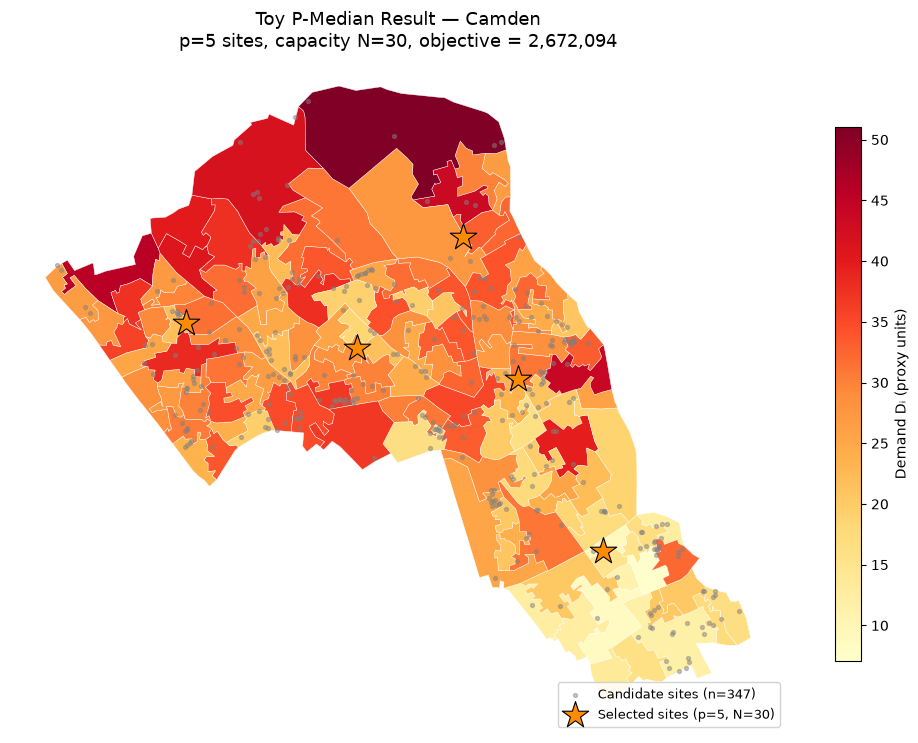

Saved to: /Users/alexia/Documents/CASA/Dissertation/06_outputs/figures/toy_model_camden.png


In [10]:
import matplotlib.pyplot as plt

selected_idx = [j for j in range(n_j) if y_cap[j].value() > 0.5]
selected_sites = candidate_sites_out.iloc[selected_idx]

fig, ax = plt.subplots(figsize=(10, 10))

# Background: Camden LSOA demand choropleth
camden_lsoa.plot(
    column="demand",
    ax=ax,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"label": "Demand Dᵢ (proxy units)", "shrink": 0.55},
    linewidth=0.3,
    edgecolor="white"
)

# All candidate parking-lot sites — grey dots
ax.scatter(
    candidate_sites_out["x"], candidate_sites_out["y"],
    color="grey", s=8, alpha=0.45,
    label=f"Candidate sites (n={len(candidate_sites_out)})", zorder=2
)

# Selected sites (capacity-constrained model) — orange stars
ax.scatter(
    selected_sites["x"], selected_sites["y"],
    color="darkorange", marker="*", s=400, edgecolor="black", linewidth=0.8,
    label=f"Selected sites (p={p}, N={N_cap})", zorder=3
)

ax.set_title(
    "Toy P-Median Result — Camden\n"
    f"p={p} sites, capacity N={N_cap}, objective = {pulp.value(prob_cap.objective):,.0f}",
    fontsize=13
)
ax.axis("off")
ax.legend(loc="lower right", fontsize=9, framealpha=0.85)

plt.tight_layout()

output_path = os.path.join(BASE, "06_outputs", "figures", "toy_model_camden.png")
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved to:", output_path)